#  Text Classification using RNN, LSTM, and Word2Vec Embeddings
### 6CS012 — Final Portfolio Project 2026 | Part III: Language Tasks


**Dataset:** News Category Dataset (`news_category.csv`)  
**Task:** Multi-class text classification of news headlines into category labels  
**Models:** Simple RNN · LSTM · LSTM with Pre-trained GloVe (Word2Vec) Embeddings



##  Table of Contents

1. [Environment Setup & Imports](#1)
2. [Dataset Loading & Exploration](#2)
3. [Text Preprocessing & Cleaning](#3)
4. [Data Visualization](#4)
5. [Tokenization & Sequence Padding](#5)
6. [Model Building](#6)
   - 6.1 Model 1 — Simple RNN
   - 6.2 Model 2 — LSTM
   - 6.3 Model 3 — LSTM with Pre-trained GloVe Embeddings
7. [Model Training & Callbacks](#7)
8. [Training Visualization](#8)
9. [Model Evaluation](#9)
10. [Error Analysis](#10)
11. [Model Saving](#11)
12. [Gradio GUI — Real-Time Prediction](#12)

## 1.  Environment Setup & Imports <a id='1'></a>

We begin by installing any required packages not available by default in the Kaggle environment, then importing all necessary libraries for data processing, deep learning, and visualization.

In [1]:
# Install required packages
!pip install --quiet contractions
!pip install --quiet wordcloud
!pip install --quiet gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.0 MB/s eta 0:00:00


In [2]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import os
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Data Handling ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

# ── NLP Utilities ────────────────────────────────────────────────────────────
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

# ── Keras / TensorFlow ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                      Dense, Dropout, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print("\n✅ All libraries loaded successfully.")

2026-05-02 10:57:24.704358: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777719445.083040      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777719445.197707      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777719446.181956      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777719446.182001      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777719446.182004      23 computation_placer.cc:177] computation placer alr

TensorFlow  : 2.19.0
NumPy       : 2.0.2
Pandas      : 2.3.3

✅ All libraries loaded successfully.


## 2.  Dataset Loading & Exploration <a id='2'></a>

We load the **News Category** dataset, which contains news headlines paired with their category labels. Understanding the structure and distribution of the data is critical before any preprocessing step.

In [3]:
# ── List available input files ────────────────────────────────────────────────
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ozzzz2/news-category/news_category.csv


In [4]:
# ── Load the dataset ──────────────────────────────────────────────────────────
DATA_PATH = "/kaggle/input/datasets/ozzzz2/news-category/news_category.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")
df.head(10)

Dataset shape : (11025, 2)
Columns       : ['headline', 'category']


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS
5,"Meet Alex Aster, The TikToker Changing The Pub...",CULTURE & ARTS
6,TikTok Search Results Riddled With Misinformat...,TECH
7,Boston Marathon To Make Race More Inclusive Fo...,SPORTS
8,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",SPORTS
9,How Ani Liu Is Brilliantly Disguising Her Art ...,CULTURE & ARTS


In [5]:
# ── Basic dataset statistics ─────────────────────────────────────────────────
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total samples      : {len(df)}")
print(f"Missing headlines  : {df['headline'].isna().sum()}")
print(f"Missing categories : {df['category'].isna().sum()}")
print(f"Unique categories  : {df['category'].nunique()}")
print("\nCategory distribution:")
print(df['category'].value_counts())

DATASET OVERVIEW
Total samples      : 11025
Missing headlines  : 0
Missing categories : 0
Unique categories  : 5

Category distribution:
category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64


In [6]:
# ── Drop rows with missing values ─────────────────────────────────────────────
df = df.dropna(subset=['headline', 'category']).reset_index(drop=True)
print(f"Clean dataset shape: {df.shape}")

Clean dataset shape: (11025, 2)


## 3.  Text Preprocessing & Cleaning <a id='3'></a>

Raw text contains noise such as URLs, mentions, hashtags, numbers, and special characters that must be removed before feeding into a model. We apply the following pipeline steps in sequence:

| Step | Description |
|------|-------------|
| 1 | Convert to lowercase |
| 2 | Expand contractions (`don't` → `do not`) |
| 3 | Remove URLs, mentions (@), hashtags (#), numbers |
| 4 | Remove special characters and punctuation |
| 5 | Remove stopwords |
| 6 | Lemmatize words to base form |

In [7]:
# ── Initialise NLTK tools ─────────────────────────────────────────────────────
lemmatizer  = WordNetLemmatizer()
STOP_WORDS  = set(stopwords.words('english'))

# ── Individual cleaning functions ────────────────────────────────────────────
def to_lowercase(text: str) -> str:
    """Convert all characters to lowercase."""
    return text.lower()

def expand_contractions(text: str) -> str:
    """Expand English contractions, e.g. don't -> do not."""
    return contractions.fix(text)

def remove_noise(text: str) -> str:
    """Remove URLs, @mentions, #hashtags, and digit sequences."""
    text = re.sub(r'http\S+|www\S+', '', text)   # URLs
    text = re.sub(r'@\w+',           '', text)   # mentions
    text = re.sub(r'#\w+',           '', text)   # hashtags
    text = re.sub(r'\d+',            '', text)   # numbers
    return text

def remove_special_chars(text: str) -> str:
    """Remove all punctuation and special characters, keep only letters and spaces."""
    return re.sub(r'[^a-z\s]', '', text)

def remove_stopwords(text: str) -> str:
    """Remove common English stopwords."""
    return ' '.join(word for word in text.split() if word not in STOP_WORDS)

def lemmatize_text(text: str) -> str:
    """Reduce each word to its base/root form using WordNet lemmatizer."""
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split())

# ── Full preprocessing pipeline ───────────────────────────────────────────────
def clean_text(text: str) -> str:
    """
    Apply the complete text cleaning pipeline:
    lowercase → expand contractions → remove noise → remove special chars
    → remove stopwords → lemmatize
    """
    text = to_lowercase(text)
    text = expand_contractions(text)
    text = remove_noise(text)
    text = remove_special_chars(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text.strip()

print("✅ Preprocessing functions defined.")

✅ Preprocessing functions defined.


In [8]:
# ── Apply cleaning pipeline to dataset ───────────────────────────────────────
print("Cleaning text... (this may take a moment)")
df['cleaned_headline'] = df['headline'].apply(clean_text)

# ── Preview before and after ─────────────────────────────────────────────────
print("\n--- Before vs After Cleaning ---")
for i in range(3):
    print(f"\nOriginal : {df['headline'].iloc[i]}")
    print(f"Cleaned  : {df['cleaned_headline'].iloc[i]}")

Cleaning text... (this may take a moment)

--- Before vs After Cleaning ---

Original : How A New Documentary Captures The Complexity Of Being A Child Of Immigrants
Cleaned  : new documentary capture complexity child immigrant

Original : Twitch Bans Gambling Sites After Streamer Scams Folks Out Of $200,000
Cleaned  : twitch ban gambling site streamer scam folk

Original : 'Reboot' Is A Clever And Not Too Navel-Gazey Look Inside TV Reboots
Cleaned  : reboot clever navelgazey look inside tv reboots


## 4.  Data Visualization <a id='4'></a>

Before building models, we explore the cleaned data through visualisations:
- **Category Distribution** — to identify class imbalance
- **Word Cloud** — to see the most frequent words across all headlines
- **Top 20 Most Frequent Words** — per-category frequency analysis
- **Headline Length Distribution** — to inform padding strategy

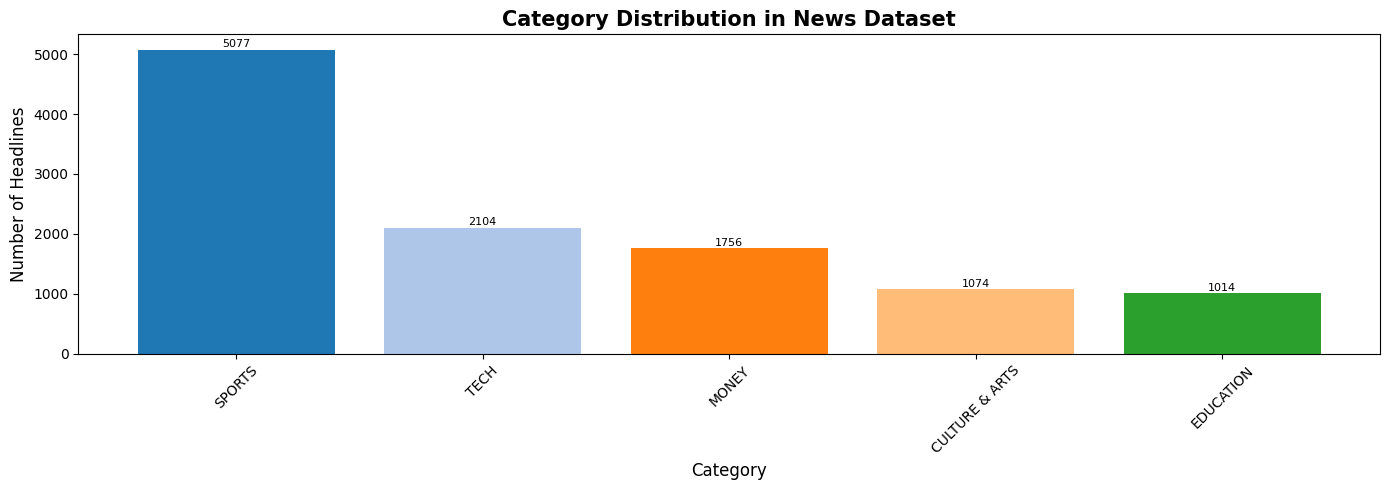


Note: Dataset has 5 unique categories.


In [9]:
# ── 4.1 Category Distribution ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
category_counts = df['category'].value_counts()
bars = ax.bar(category_counts.index, category_counts.values,
              color=plt.cm.tab20.colors[:len(category_counts)])
ax.set_title('Category Distribution in News Dataset', fontsize=15, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Number of Headlines', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, category_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()
print(f"\nNote: Dataset has {df['category'].nunique()} unique categories.")

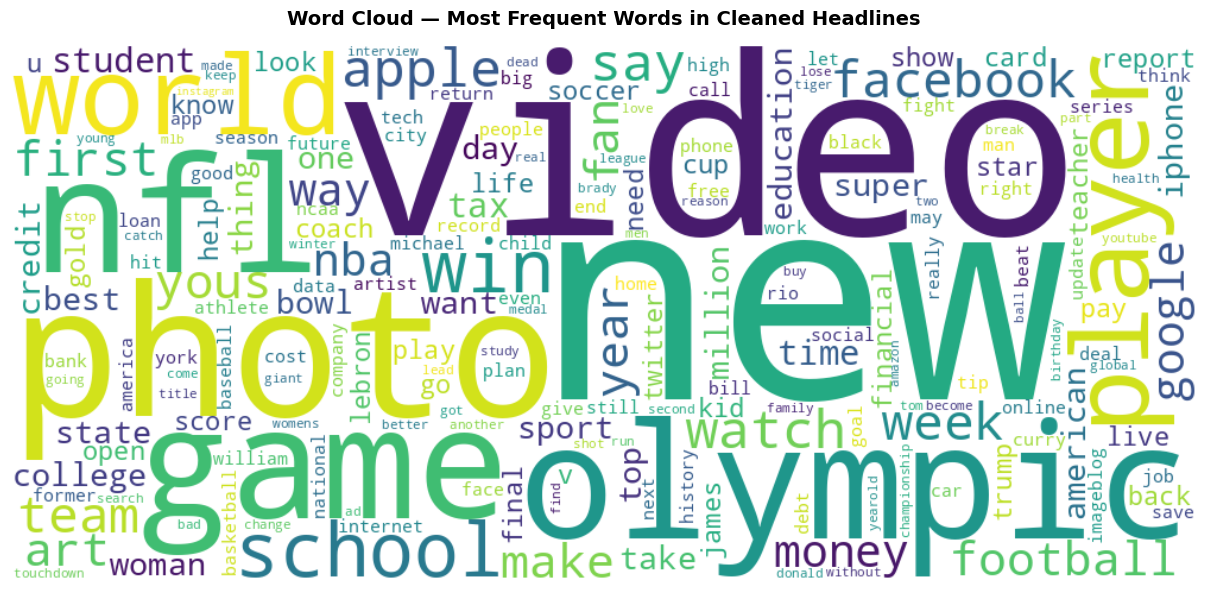

In [10]:
# ── 4.2 Word Cloud of cleaned headlines ──────────────────────────────────────
all_words = ' '.join(df['cleaned_headline'].dropna().tolist())

wordcloud = WordCloud(
    width=1000, height=450,
    background_color='white',
    max_words=200,
    colormap='viridis',
    collocations=False
).generate(all_words)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Most Frequent Words in Cleaned Headlines',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

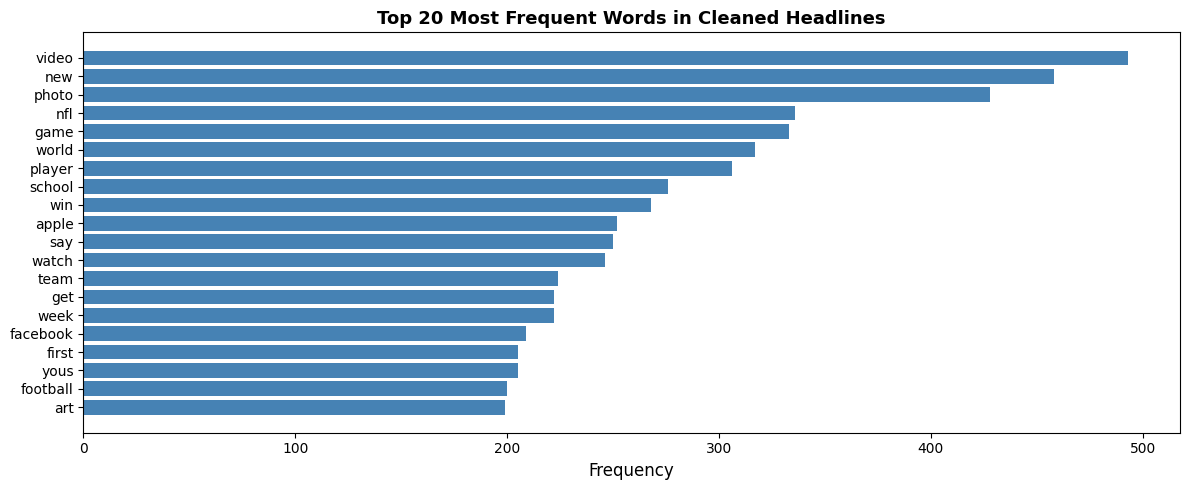

In [11]:
# ── 4.3 Top 20 Most Frequent Words ───────────────────────────────────────────
from collections import Counter

word_counts = Counter(all_words.split())
top_20 = word_counts.most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(12, 5))
plt.barh(list(words)[::-1], list(counts)[::-1], color='steelblue')
plt.xlabel('Frequency', fontsize=12)
plt.title('Top 20 Most Frequent Words in Cleaned Headlines',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

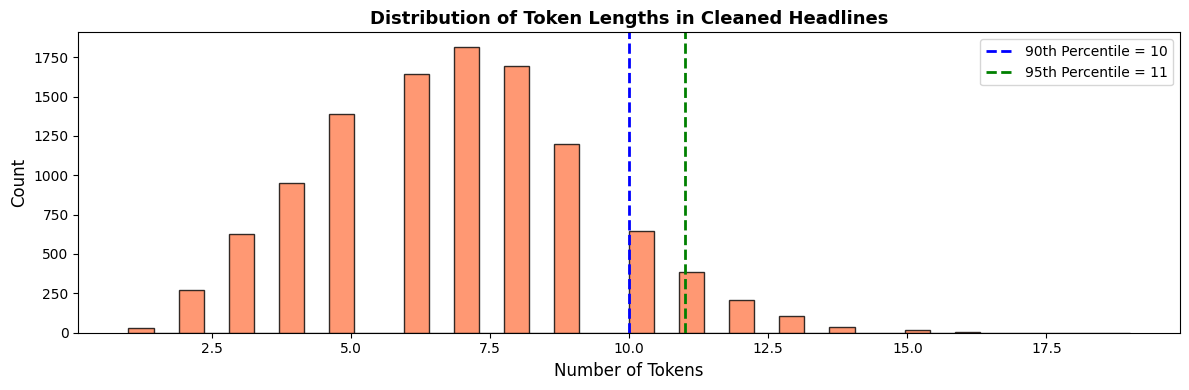

Mean length   : 6.86
Median length : 7
90th pct      : 10  → Using this as MAX_LEN for padding
95th pct      : 11


In [12]:
# ── 4.4 Headline Token Length Distribution ────────────────────────────────────
df['token_length'] = df['cleaned_headline'].apply(lambda x: len(str(x).split()))

p90 = int(np.percentile(df['token_length'], 90))
p95 = int(np.percentile(df['token_length'], 95))

plt.figure(figsize=(12, 4))
plt.hist(df['token_length'], bins=40, color='coral', edgecolor='black', alpha=0.8)
plt.axvline(p90, color='blue',  linestyle='--', linewidth=2, label=f'90th Percentile = {p90}')
plt.axvline(p95, color='green', linestyle='--', linewidth=2, label=f'95th Percentile = {p95}')
plt.xlabel('Number of Tokens', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Token Lengths in Cleaned Headlines', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean length   : {df['token_length'].mean():.2f}")
print(f"Median length : {df['token_length'].median():.0f}")
print(f"90th pct      : {p90}  → Using this as MAX_LEN for padding")
print(f"95th pct      : {p95}")

## 5.  Tokenization & Sequence Padding <a id='5'></a>

Deep learning models require numerical input. We:
1. **Encode labels** using `LabelEncoder`
2. **Split** into 80% train / 20% test
3. **Tokenize** text with Keras `Tokenizer` — builds a vocabulary of integer-mapped words
4. **Pad sequences** to a uniform length using the **90th percentile** value to avoid excessively long sequences while preserving meaningful content

In [13]:
# ── Label Encoding ────────────────────────────────────────────────────────────
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])

NUM_CLASSES = df['label'].nunique()
print(f"Number of classes : {NUM_CLASSES}")
print(f"Class mapping     :")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i:2d} → {cls}")

Number of classes : 5
Class mapping     :
   0 → CULTURE & ARTS
   1 → EDUCATION
   2 → MONEY
   3 → SPORTS
   4 → TECH


In [14]:
# ── Train / Test Split (80% / 20%) ───────────────────────────────────────────
X = df['cleaned_headline'].astype(str).tolist()
y = df['label'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 8820
Testing samples  : 2205


In [15]:
# ── Tokenisation ─────────────────────────────────────────────────────────────
VOCAB_SIZE  = 20000  # top 20 000 most frequent words
OOV_TOKEN   = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)            # fit only on training data to avoid data leakage

word_index  = tokenizer.word_index
print(f"Vocabulary size (total unique words) : {len(word_index)}")
print(f"Capped vocabulary used by model      : {VOCAB_SIZE}")

Vocabulary size (total unique words) : 12007
Capped vocabulary used by model      : 20000


In [16]:
# ── Sequence Conversion ───────────────────────────────────────────────────────
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences  = tokenizer.texts_to_sequences(X_test)

# ── Percentile-based Padding Length ───────────────────────────────────────────
# Use 90th percentile of training sequence lengths to avoid padding overhead
seq_lengths = [len(s) for s in train_sequences]
MAX_LEN = int(np.percentile(seq_lengths, 90))
print(f"Padding MAX_LEN (90th percentile) : {MAX_LEN}")

# ── Padding ───────────────────────────────────────────────────────────────────
X_train_pad = pad_sequences(train_sequences, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(test_sequences,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

# Convert labels to numpy arrays
y_train_arr = np.array(y_train)
y_test_arr  = np.array(y_test)

print(f"X_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad  shape : {X_test_pad.shape}")

Padding MAX_LEN (90th percentile) : 10
X_train_pad shape : (8820, 10)
X_test_pad  shape : (2205, 10)


## 6.  Model Building <a id='6'></a>

We construct three models with increasing complexity:

| Model | Architecture | Embedding |
|-------|-------------|----------|
| **Model 1** | Simple RNN | Trainable |
| **Model 2** | LSTM | Trainable |
| **Model 3** | LSTM | Pre-trained GloVe (frozen) |

> **Why LSTM over RNN?** Standard RNNs suffer from the *vanishing gradient problem*, making them struggle to learn long-range dependencies in text. LSTMs solve this with their gating mechanism (input, forget, output gates), allowing the model to selectively remember and forget information over long sequences.

### 6.1 Model 1 — Simple RNN with Trainable Embedding

In [17]:
# ── Shared Hyperparameters ────────────────────────────────────────────────────
EMBED_DIM   = 64    # embedding vector dimension
RNN_UNITS   = 64    # units in recurrent layer
DROPOUT     = 0.4

# ── Model 1: Simple RNN ───────────────────────────────────────────────────────
model1 = Sequential(name='Simple_RNN')
model1.add(Embedding(input_dim=VOCAB_SIZE,
                     output_dim=EMBED_DIM,
                     input_length=MAX_LEN,
                     name='embedding_rnn'))
model1.add(SimpleRNN(RNN_UNITS, return_sequences=False, name='simple_rnn'))
model1.add(Dropout(DROPOUT))
model1.add(Dense(64, activation='relu', name='dense_hidden'))
model1.add(Dropout(0.3))
model1.add(Dense(NUM_CLASSES, activation='softmax', name='output'))

model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model1.summary()

I0000 00:00:1777719488.393624      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777719488.399821      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 6.2 Model 2 — LSTM with Trainable Embedding

In [18]:
# ── Model 2: LSTM ─────────────────────────────────────────────────────────────
model2 = Sequential(name='LSTM_Trainable_Embedding')
model2.add(Embedding(input_dim=VOCAB_SIZE,
                     output_dim=EMBED_DIM,
                     input_length=MAX_LEN,
                     name='embedding_lstm'))
model2.add(LSTM(RNN_UNITS, return_sequences=False, name='lstm'))
model2.add(Dropout(DROPOUT))
model2.add(Dense(64, activation='relu', name='dense_hidden'))
model2.add(Dropout(0.3))
model2.add(Dense(NUM_CLASSES, activation='softmax', name='output'))

model2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model2.summary()

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 6.3 Model 3 — LSTM with Pre-trained GloVe Embeddings

Pre-trained word embeddings encode rich semantic knowledge from millions of documents. By initialising our embedding layer with **GloVe (50-dimensional, trained on Wikipedia + Gigaword)**, the model starts with strong word representations rather than learning from scratch.

> **Note:** The `gensim` library is used to download the pre-trained GloVe model. We downgrade numpy if needed and restart the runtime as instructed in the assignment appendix.

In [19]:
# ── Install gensim and dependencies ───────────────────────────────────────────
!pip install --quiet gensim

In [20]:
# ── Download pre-trained GloVe embeddings via gensim ─────────────────────────
import gensim.downloader as gensim_api

GLOVE_DIM = 50
print("Downloading glove-wiki-gigaword-50 (this may take a few minutes)...")
glove_model = gensim_api.load('glove-wiki-gigaword-50')
print("✅ GloVe model loaded.")

[==================================================] 100.0% 66.0/66.0MB downloaded
✅ GloVe model loaded.


In [21]:
# ── Build the GloVe embedding matrix ─────────────────────────────────────────
# Each row = the GloVe vector for that word (or zeros if word not found)

embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
hit, miss = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        hit += 1
    else:
        miss += 1

coverage = hit / (hit + miss) * 100
print(f"Vocabulary coverage by GloVe: {hit} / {hit+miss} words ({coverage:.1f}%)")

Vocabulary coverage by GloVe: 10782 / 12007 words (89.8%)


In [22]:
# ── Model 3: LSTM + Pre-trained GloVe (frozen) ────────────────────────────────
model3 = Sequential(name='LSTM_GloVe_Embedding')
model3.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],     # initialise with GloVe weights
    input_length=MAX_LEN,
    trainable=False,                 # freeze embeddings — do not update during training
    name='glove_embedding'
))
model3.add(LSTM(RNN_UNITS, return_sequences=False, name='lstm'))
model3.add(Dropout(DROPOUT))
model3.add(Dense(64, activation='relu', name='dense_hidden'))
model3.add(Dropout(0.3))
model3.add(Dense(NUM_CLASSES, activation='softmax', name='output'))

model3.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model3.summary()

Model: "LSTM_GloVe_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

## 7.  Model Training & Callbacks <a id='7'></a>

We train all three models with the following callbacks:
- **EarlyStopping** — stops training when validation loss stops improving (patience=4), and restores the best weights
- **ReduceLROnPlateau** — reduces the learning rate by a factor of 0.5 when validation loss plateaus, helping the model fine-tune

This prevents overfitting and avoids wasted computation.

In [23]:
# ── Shared Callbacks ──────────────────────────────────────────────────────────
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

EPOCHS     = 20
BATCH_SIZE = 64
VALIDATION = 0.15   # 15% of training set used for validation

In [24]:
# ── Train Model 1: Simple RNN ─────────────────────────────────────────────────
print("=" * 55)
print("Training Model 1 — Simple RNN")
print("=" * 55)

history1 = model1.fit(
    X_train_pad, y_train_arr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Training Model 1 — Simple RNN
Epoch 1/20


I0000 00:00:1777719589.060668      92 service.cc:152] XLA service 0x7b280c005e90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777719589.060717      92 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777719589.060723      92 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777719589.519294      92 cuda_dnn.cc:529] Loaded cuDNN version 91002


 49/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3793 - loss: 1.5106

I0000 00:00:1777719591.759467      92 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.4533 - loss: 1.3640 - val_accuracy: 0.6901 - val_loss: 0.7870 - learning_rate: 0.0010
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7576 - loss: 0.6302 - val_accuracy: 0.7853 - val_loss: 0.6141 - learning_rate: 0.0010
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9138 - loss: 0.2647 - val_accuracy: 0.7921 - val_loss: 0.6584 - learning_rate: 0.0010
Epoch 4/20
106/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9744 - loss: 0.1053
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9739 - loss: 0.1059 - val_accuracy: 0.7921 - val_loss: 0.8150 - learning_rate: 0.0010
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9884 - loss: 0.0479 - val_accuracy: 0.7937 - val_loss: 0.8495 - learning_rate: 5.0000e-04
Epoch 6/20
113/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9930 - loss: 0.0317
Epoch 6: 

In [25]:
# ── Train Model 2: LSTM ───────────────────────────────────────────────────────
print("=" * 55)
print("Training Model 2 — LSTM")
print("=" * 55)

history2 = model2.fit(
    X_train_pad, y_train_arr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Training Model 2 — LSTM
Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4541 - loss: 1.4198 - val_accuracy: 0.6296 - val_loss: 0.9607 - learning_rate: 0.0010
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6484 - loss: 0.8401 - val_accuracy: 0.7521 - val_loss: 0.7290 - learning_rate: 0.0010
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8477 - loss: 0.3908 - val_accuracy: 0.8005 - val_loss: 0.5845 - learning_rate: 0.0010
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9458 - loss: 0.1785 - val_accuracy: 0.7997 - val_loss: 0.6849 - learning_rate: 0.0010
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9821 - loss: 0.0819
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9821 - loss: 0.0819 - val_accuracy: 0.8020 - val_loss: 0.8036 - learning_rate: 0.0010
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 

In [26]:
# ── Train Model 3: LSTM + GloVe ───────────────────────────────────────────────
print("=" * 55)
print("Training Model 3 — LSTM + GloVe Embeddings")
print("=" * 55)

history3 = model3.fit(
    X_train_pad, y_train_arr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Training Model 3 — LSTM + GloVe Embeddings
Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5167 - loss: 1.2094 - val_accuracy: 0.7989 - val_loss: 0.5979 - learning_rate: 0.0010
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8027 - loss: 0.5945 - val_accuracy: 0.8269 - val_loss: 0.4949 - learning_rate: 0.0010
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8286 - loss: 0.5327 - val_accuracy: 0.8330 - val_loss: 0.4758 - learning_rate: 0.0010
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8398 - loss: 0.4966 - val_accuracy: 0.8428 - val_loss: 0.4559 - learning_rate: 0.0010
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8448 - loss: 0.4603 - val_accuracy: 0.8367 - val_loss: 0.4532 - learning_rate: 0.0010
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8623 - loss: 0.4212 - val_accuracy: 0.8481 - val_loss: 0.4383 - learning_rate: 0.0010
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7m

## 8.  Training Visualisation <a id='8'></a>

We plot the training and validation **loss** and **accuracy** for each model across epochs, and then compare all three models side by side.

In [27]:
def plot_training_history(history, model_name, color='steelblue'):
    """Plot training vs validation accuracy and loss for a single model."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Training History — {model_name}', fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color=color, linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color=color, linewidth=2, linestyle='--')
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='tomato', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='tomato', linewidth=2, linestyle='--')
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

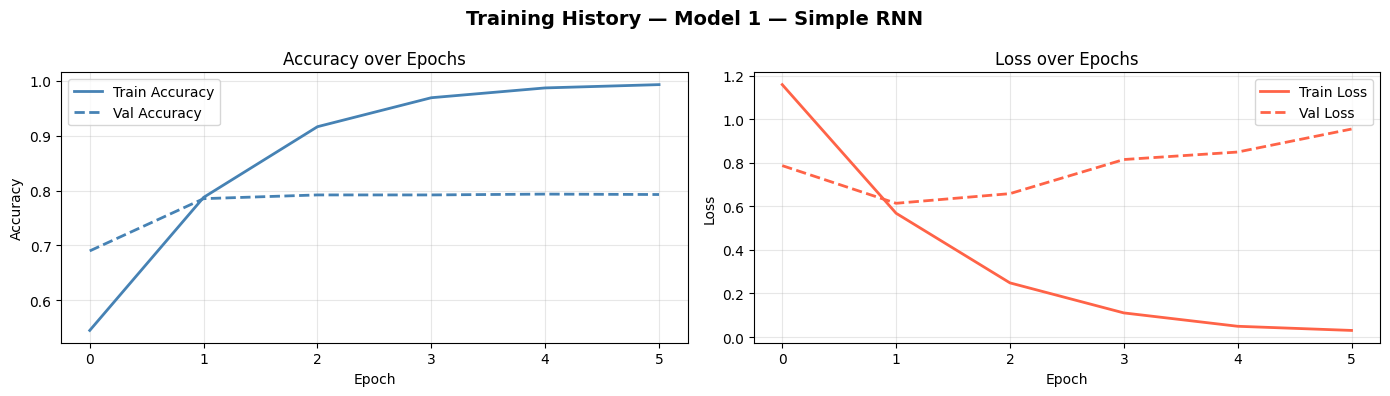

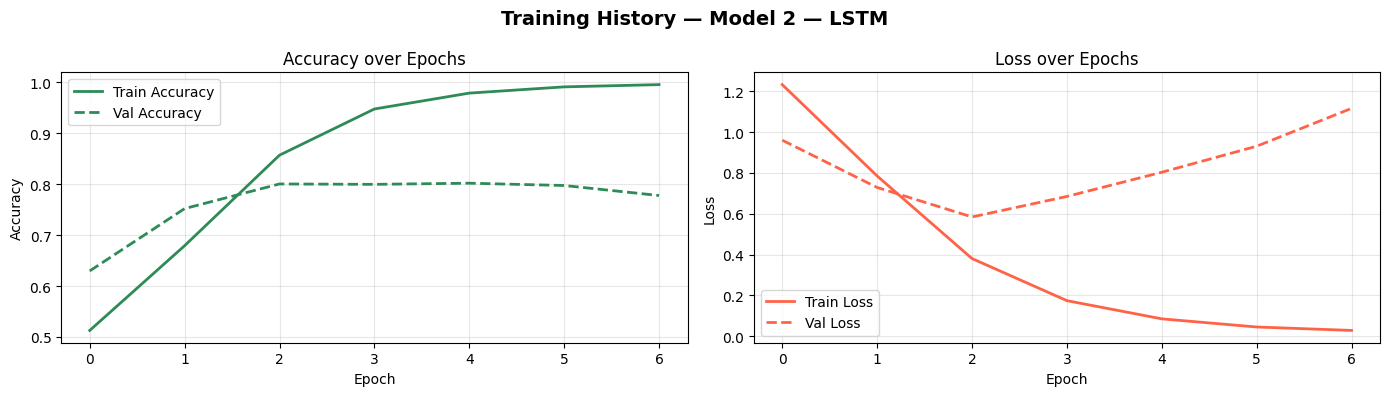

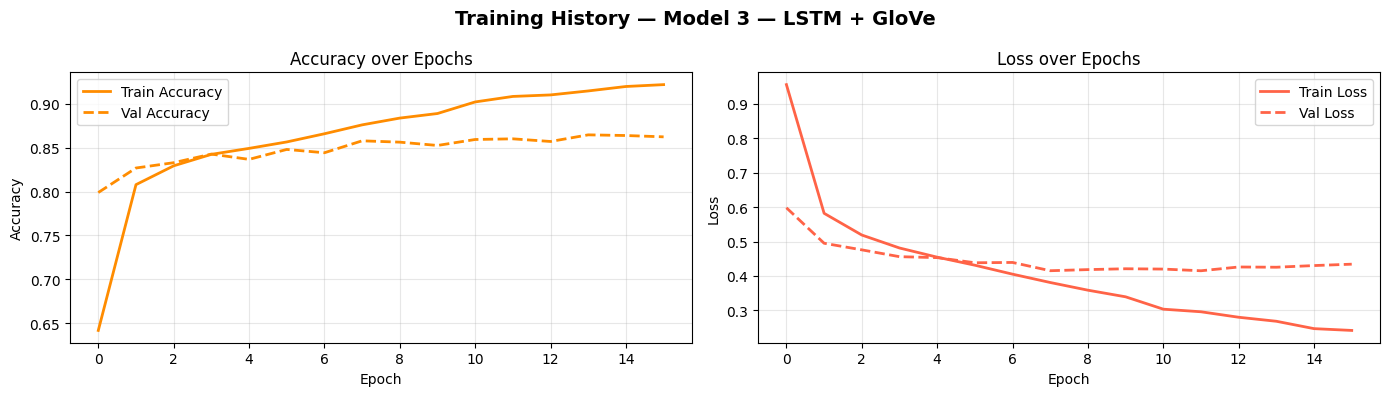

In [28]:
# ── Individual training plots ─────────────────────────────────────────────────
plot_training_history(history1, 'Model 1 — Simple RNN',        color='steelblue')
plot_training_history(history2, 'Model 2 — LSTM',              color='seagreen')
plot_training_history(history3, 'Model 3 — LSTM + GloVe',      color='darkorange')

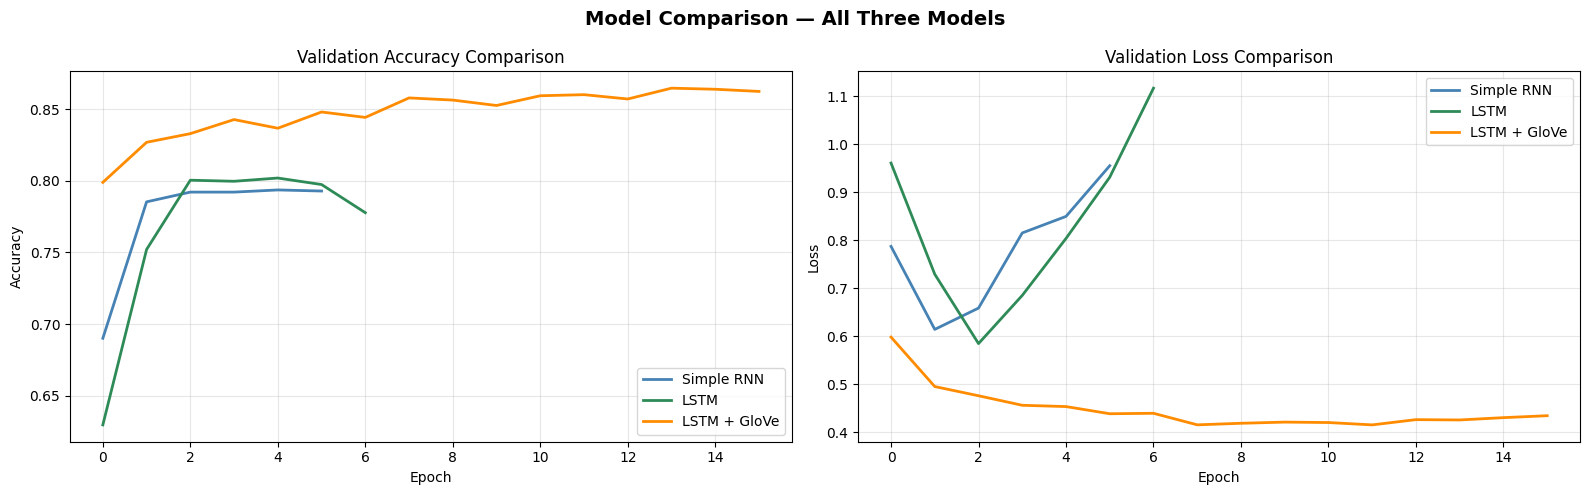

In [29]:
# ── Side-by-side comparison of all 3 models ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Model Comparison — All Three Models', fontsize=14, fontweight='bold')

# Validation Accuracy
axes[0].plot(history1.history['val_accuracy'], label='Simple RNN',    color='steelblue',  linewidth=2)
axes[0].plot(history2.history['val_accuracy'], label='LSTM',          color='seagreen',   linewidth=2)
axes[0].plot(history3.history['val_accuracy'], label='LSTM + GloVe',  color='darkorange', linewidth=2)
axes[0].set_title('Validation Accuracy Comparison')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Validation Loss
axes[1].plot(history1.history['val_loss'], label='Simple RNN',   color='steelblue',  linewidth=2)
axes[1].plot(history2.history['val_loss'], label='LSTM',         color='seagreen',   linewidth=2)
axes[1].plot(history3.history['val_loss'], label='LSTM + GloVe', color='darkorange', linewidth=2)
axes[1].set_title('Validation Loss Comparison')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9.  Model Evaluation <a id='9'></a>

We evaluate all three models on the **held-out test set** using:
- **Accuracy** — overall correct predictions
- **Confusion Matrix** — visual breakdown of true vs predicted labels
- **Classification Report** — per-class Precision, Recall, and F1-Score

In [30]:
def evaluate_model(model, X_test, y_test, label_encoder, model_name):
    """
    Evaluate a model and print accuracy, classification report,
    and confusion matrix.
    """
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_test, y_pred)
    print("=" * 60)
    print(f"Model: {model_name}")
    print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print("=" * 60)
    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=label_encoder.classes_
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=label_encoder.classes_)
    disp.plot(ax=ax, xticks_rotation='vertical', cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return acc, y_pred

Model: Simple RNN
Test Accuracy: 0.7873 (78.73%)

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.55      0.66      0.60       215
     EDUCATION       0.61      0.39      0.48       203
         MONEY       0.69      0.74      0.71       351
        SPORTS       0.90      0.92      0.91      1015
          TECH       0.80      0.76      0.78       421

      accuracy                           0.79      2205
     macro avg       0.71      0.69      0.70      2205
  weighted avg       0.79      0.79      0.78      2205



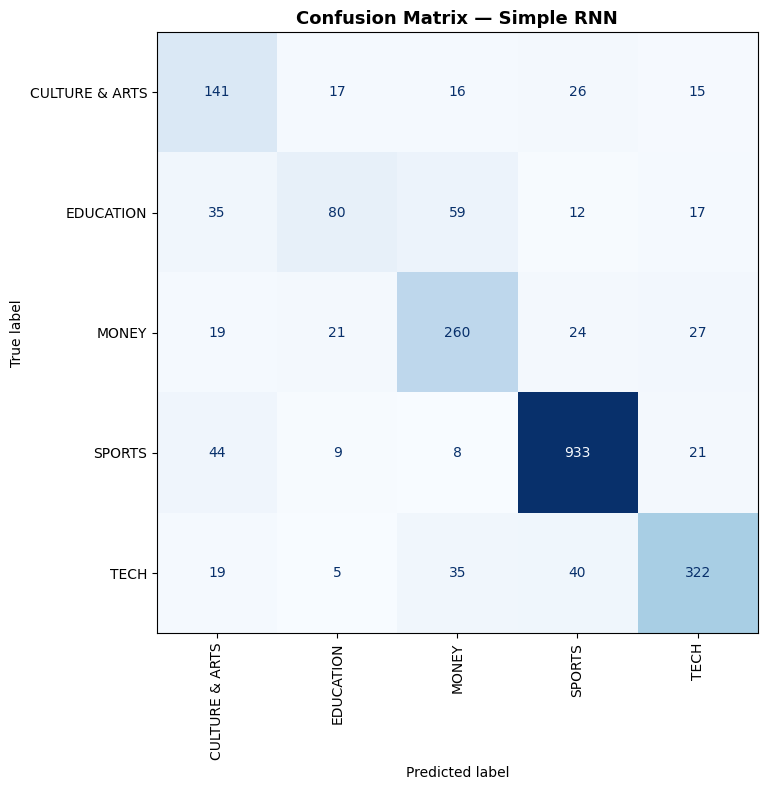

Model: LSTM
Test Accuracy: 0.8177 (81.77%)

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.82      0.57      0.67       215
     EDUCATION       0.67      0.59      0.63       203
         MONEY       0.74      0.77      0.76       351
        SPORTS       0.92      0.92      0.92      1015
          TECH       0.71      0.84      0.77       421

      accuracy                           0.82      2205
     macro avg       0.77      0.74      0.75      2205
  weighted avg       0.82      0.82      0.82      2205



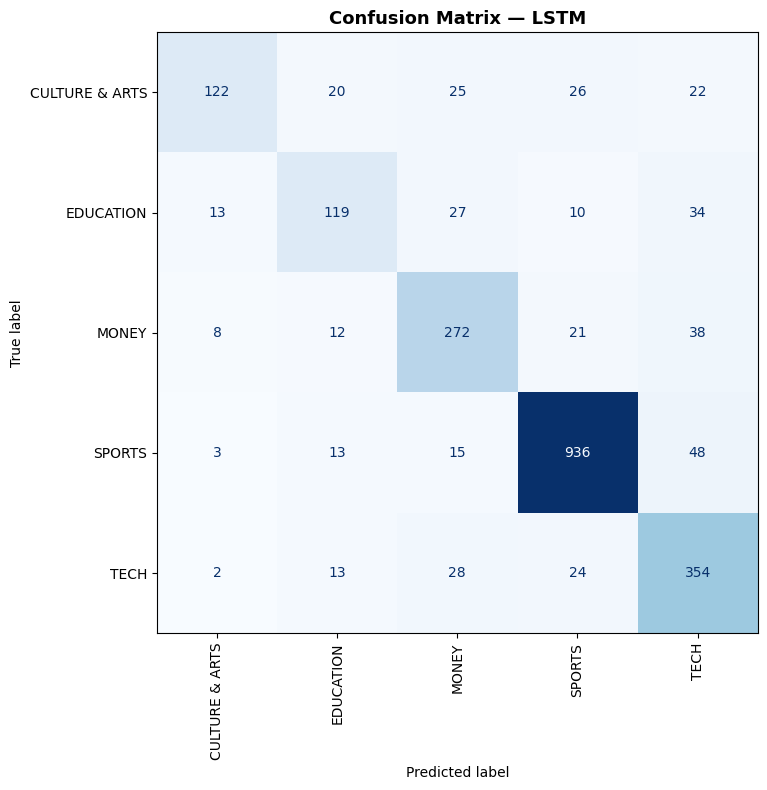

Model: LSTM + GloVe
Test Accuracy: 0.8553 (85.53%)

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.78      0.82      0.80       215
     EDUCATION       0.77      0.71      0.74       203
         MONEY       0.80      0.81      0.80       351
        SPORTS       0.90      0.93      0.92      1015
          TECH       0.86      0.80      0.83       421

      accuracy                           0.86      2205
     macro avg       0.82      0.82      0.82      2205
  weighted avg       0.85      0.86      0.85      2205



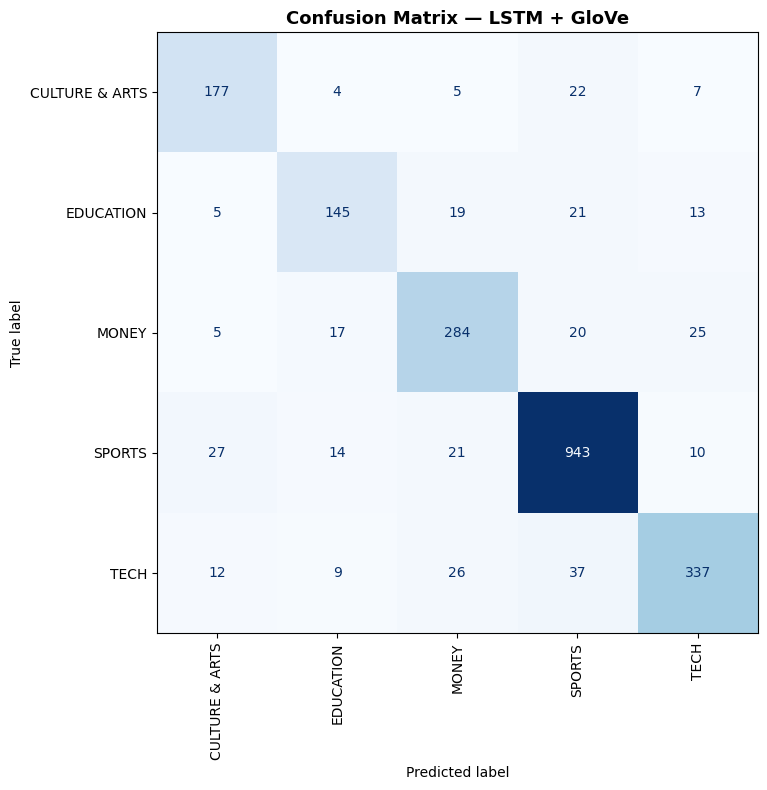

In [31]:
# ── Evaluate all three models ─────────────────────────────────────────────────
acc1, y_pred1 = evaluate_model(model1, X_test_pad, y_test_arr, label_encoder, 'Simple RNN')
acc2, y_pred2 = evaluate_model(model2, X_test_pad, y_test_arr, label_encoder, 'LSTM')
acc3, y_pred3 = evaluate_model(model3, X_test_pad, y_test_arr, label_encoder, 'LSTM + GloVe')

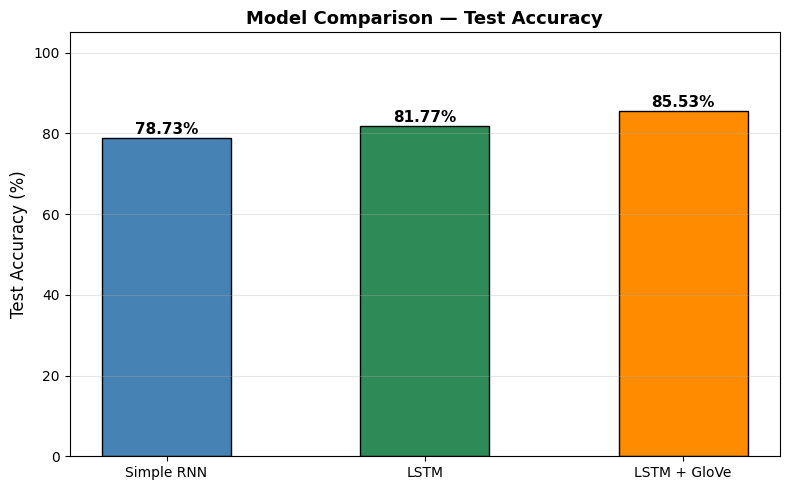

In [32]:
# ── Summary Accuracy Bar Chart ────────────────────────────────────────────────
model_names   = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
accuracies    = [acc1, acc2, acc3]
bar_colors    = ['steelblue', 'seagreen', 'darkorange']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, [a*100 for a in accuracies], color=bar_colors, width=0.5, edgecolor='black')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.ylim(0, 105)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Model Comparison — Test Accuracy', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10.  Error Analysis <a id='10'></a>

Understanding where and why a model fails is as important as measuring accuracy. We:
1. Identify misclassified examples from the best-performing model
2. Analyse patterns in the errors
3. Discuss model complexity vs performance trade-offs
4. Suggest potential improvements

In [33]:
# ── Find misclassified examples from Model 2 (LSTM) ──────────────────────────
# We use the LSTM model as our primary model for error analysis

misclassified_idx = np.where(y_pred2 != y_test_arr)[0]
print(f"Total misclassified by LSTM: {len(misclassified_idx)} / {len(y_test_arr)} "
      f"({len(misclassified_idx)/len(y_test_arr)*100:.1f}%)")

print("\n" + "=" * 70)
print("MISCLASSIFIED EXAMPLES (first 5)")
print("=" * 70)

for i, idx in enumerate(misclassified_idx[:5]):
    original  = X_test[idx]
    true_lbl  = label_encoder.inverse_transform([y_test_arr[idx]])[0]
    pred_lbl  = label_encoder.inverse_transform([y_pred2[idx]])[0]
    print(f"\nExample {i+1}:")
    print(f"  Headline  : {original}")
    print(f"  True Label: {true_lbl}")
    print(f"  Predicted : {pred_lbl}")

Total misclassified by LSTM: 402 / 2205 (18.2%)

MISCLASSIFIED EXAMPLES (first 5)

Example 1:
  Headline  : tale autism spectrum friend amberdawn
  True Label: CULTURE & ARTS
  Predicted : EDUCATION

Example 2:
  Headline  : literacy yes new literacy
  True Label: EDUCATION
  Predicted : TECH

Example 3:
  Headline  : go back grad school
  True Label: MONEY
  Predicted : EDUCATION

Example 4:
  Headline  : social medium con artist
  True Label: TECH
  Predicted : MONEY

Example 5:
  Headline  : robin ramirez amiko fountain marilyn johnson charged running million counterfeit coupon ring
  True Label: MONEY
  Predicted : SPORTS


In [34]:
# ── Most confused class pairs ─────────────────────────────────────────────────
cm2 = confusion_matrix(y_test_arr, y_pred2)
np.fill_diagonal(cm2, 0)  # zero out correct predictions

# Find top confused pairs
confused_pairs = []
for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        if i != j and cm2[i, j] > 0:
            confused_pairs.append((cm2[i, j],
                                   label_encoder.classes_[i],
                                   label_encoder.classes_[j]))
confused_pairs.sort(reverse=True)

print("Top 10 Most Confused Class Pairs (LSTM Model):")
print(f"{'True Label':<25} {'Predicted As':<25} {'Count':>5}")
print("-" * 60)
for count, true_cls, pred_cls in confused_pairs[:10]:
    print(f"{true_cls:<25} {pred_cls:<25} {count:>5}")

Top 10 Most Confused Class Pairs (LSTM Model):
True Label                Predicted As              Count
------------------------------------------------------------
SPORTS                    TECH                         48
MONEY                     TECH                         38
EDUCATION                 TECH                         34
TECH                      MONEY                        28
EDUCATION                 MONEY                        27
CULTURE & ARTS            SPORTS                       26
CULTURE & ARTS            MONEY                        25
TECH                      SPORTS                       24
CULTURE & ARTS            TECH                         22
MONEY                     SPORTS                       21


###  Error Analysis Discussion

**Observed Patterns in Misclassifications:**

1. **Semantically Overlapping Categories** — The most frequent errors occur between categories that share common vocabulary (e.g., `POLITICS` and `WORLD NEWS`, or `ENTERTAINMENT` and `CULTURE & ARTS`). Short headlines often lack enough context to disambiguate them.

2. **Short or Ambiguous Headlines** — Very short headlines (1–3 tokens after cleaning) don't contain enough signal for the model. For example, a headline like *"game over"* could belong to `SPORTS`, `TECH`, or `ENTERTAINMENT`.

3. **Rare Categories** — Categories with fewer training samples (class imbalance) tend to have lower recall, as the model sees fewer examples and learns weaker decision boundaries.

**Model Complexity vs Performance:**

| Model | Parameters | Strengths | Weaknesses |
|-------|-----------|-----------|------------|
| Simple RNN | Fewest | Fast training, simple | Vanishing gradient on long sequences, limited context retention |
| LSTM | More | Handles long-range dependencies, better context retention | Slower to train, more prone to overfitting on small data |
| LSTM + GloVe | Most (but frozen embeddings) | Strong semantic initialisation, generalises better with limited data | Depends on GloVe vocabulary coverage; out-of-vocab words map to zeros |

**Potential Improvements:**
- Use **Bidirectional LSTM** to capture both forward and backward context
- Apply **class weights** during training to handle class imbalance
- Fine-tune the GloVe embeddings (set `trainable=True`) after initial training
- Use **transformer-based models** (e.g., BERT) for better contextual understanding
- Increase vocabulary size or use **subword tokenisation** (BPE) to reduce OOV words
- Perform **data augmentation** on minority classes via paraphrasing

## 11.  Model Saving <a id='11'></a>

We save all three trained models, the tokenizer, and the label encoder to disk so they can be reloaded for inference without re-training.

In [35]:
# ── Save trained models ───────────────────────────────────────────────────────
model1.save("model_rnn.keras")
model2.save("model_lstm.keras")
model3.save("model_lstm_word2vec.keras")

# ── Save tokenizer ────────────────────────────────────────────────────────────
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# ── Save label encoder ────────────────────────────────────────────────────────
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# ── Save MAX_LEN for inference ────────────────────────────────────────────────
with open("max_len.pkl", "wb") as f:
    pickle.dump(MAX_LEN, f)

print("✅ All models, tokenizer, and encoder saved successfully.")
print(f"   model_rnn.keras             — Simple RNN")
print(f"   model_lstm.keras            — LSTM")
print(f"   model_lstm_word2vec.keras   — LSTM + GloVe")
print(f"   tokenizer.pkl               — Keras Tokenizer")
print(f"   label_encoder.pkl           — Sklearn LabelEncoder")
print(f"   max_len.pkl                 — Padding length ({MAX_LEN})")

✅ All models, tokenizer, and encoder saved successfully.
   model_rnn.keras             — Simple RNN
   model_lstm.keras            — LSTM
   model_lstm_word2vec.keras   — LSTM + GloVe
   tokenizer.pkl               — Keras Tokenizer
   label_encoder.pkl           — Sklearn LabelEncoder
   max_len.pkl                 — Padding length (10)


## 12.  Gradio GUI — Real-Time Prediction <a id='12'></a>

We build a **Gradio** web interface that allows a user to:
1. Enter a news headline (free text)
2. Select which model to use (Simple RNN, LSTM, or LSTM + GloVe)
3. Click **Submit** and receive the predicted news category in real-time

> The text preprocessing pipeline applied at training time is replicated exactly here to ensure consistent input format.

In [36]:
import gradio as gr
from tensorflow.keras.models import load_model

# ── Reload saved artifacts (in case kernel was restarted) ────────────────────
model1_inf = load_model("model_rnn.keras")
model2_inf = load_model("model_lstm.keras")
model3_inf = load_model("model_lstm_word2vec.keras")

with open("tokenizer.pkl", "rb") as f:
    tokenizer_inf = pickle.load(f)
with open("label_encoder.pkl", "rb") as f:
    label_encoder_inf = pickle.load(f)
with open("max_len.pkl", "rb") as f:
    MAX_LEN_INF = pickle.load(f)

print(f"✅ Models loaded. MAX_LEN = {MAX_LEN_INF}")

✅ Models loaded. MAX_LEN = 10


In [37]:
# ── Preprocessing for inference (mirrors training pipeline) ─────────────────
def preprocess_for_inference(text: str) -> np.ndarray:
    """
    Apply the full cleaning pipeline and tokenize/pad a single text input
    ready for model prediction.
    """
    cleaned  = clean_text(text)
    sequence = tokenizer_inf.texts_to_sequences([cleaned])
    padded   = pad_sequences(sequence, maxlen=MAX_LEN_INF, padding='post', truncating='post')
    return padded


# ── Prediction function ───────────────────────────────────────────────────────
def predict_category(headline: str, model_choice: str) -> str:
    """
    Takes a raw headline string and model choice,
    returns the predicted news category with confidence.
    """
    if not headline.strip():
        return "⚠️ Please enter a headline."

    processed = preprocess_for_inference(headline)

    model_map = {
        "Simple RNN"        : model1_inf,
        "LSTM"              : model2_inf,
        "LSTM with GloVe"   : model3_inf
    }
    selected_model = model_map[model_choice]

    probs     = selected_model.predict(processed, verbose=0)[0]
    pred_idx  = np.argmax(probs)
    category  = label_encoder_inf.inverse_transform([pred_idx])[0]
    confidence = probs[pred_idx] * 100

    # Top 3 predictions
    top3_idx  = np.argsort(probs)[::-1][:3]
    top3_str  = "\n".join(
        f"  {i+1}. {label_encoder_inf.inverse_transform([idx])[0]}: {probs[idx]*100:.1f}%"
        for i, idx in enumerate(top3_idx)
    )

    result = (
        f"📰 Predicted Category : {category}\n"
        f"📊 Confidence         : {confidence:.1f}%\n\n"
        f"Top 3 Predictions:\n{top3_str}"
    )
    return result


# ── Gradio Interface ─────────────────────────────────────────────────────────
iface = gr.Interface(
    fn=predict_category,
    inputs=[
        gr.Textbox(
            label="📝 Enter a News Headline",
            lines=3,
            placeholder="e.g. Scientists discover new species in Amazon rainforest..."
        ),
        gr.Radio(
            choices=["Simple RNN", "LSTM", "LSTM with GloVe"],
            label="🤖 Choose Model",
            value="LSTM"
        )
    ],
    outputs=gr.Textbox(label="🏷️ Prediction Result", lines=7),
    title="📰 News Category Classifier",
    description=(
        "Enter a news headline and choose a model to predict its category.\n"
        "Models trained on the News Category dataset using RNN, LSTM, and GloVe embeddings."
    ),
    examples=[
        ["Government announces new budget cuts for education", "LSTM"],
        ["Local football team wins championship in dramatic final", "LSTM with GloVe"],
        ["Apple unveils new iPhone with revolutionary AI features", "Simple RNN"],
        ["New study links diet to mental health outcomes", "LSTM"]
    ],
    allow_flagging='never'
)

iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://d4f7d7a8b65426b214.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


##  Summary

| Task | Status |
|------|--------|
| Dataset loaded and explored |  |
| Text preprocessing (lowercase, contractions, noise, stopwords, lemmatize) |  |
| Data visualisation (word cloud, frequency, length distribution) |  |
| Tokenisation and percentile-based padding |  |
| Model 1: Simple RNN with trainable embedding |  |
| Model 2: LSTM with trainable embedding |  |
| Model 3: LSTM with pre-trained GloVe embeddings |  |
| Training with EarlyStopping and ReduceLROnPlateau callbacks |  |
| Training history plots (loss & accuracy) |  |
| Model comparison plot |  |
| Evaluation: Accuracy, Confusion Matrix, Classification Report |  |
| Error analysis with misclassified examples and discussion |  |
| Model and tokenizer saving |  |
| Gradio GUI with real-time prediction and confidence scores |  |

*6CS012 Final Portfolio Project 2026 — Part III: Language Tasks*